In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
open_csv = ("loan_applications-selected-columns.csv")

df_mentah = pd.read_csv(open_csv, encoding="cp1252", sep=',', skiprows=0,nrows=1500, usecols=lambda x:x not in ["id", "medicine_image", "medicine_company", "created_at", "updated_at"])

print(df_mentah)

                            application_id customer_id application_date       loan_type  loan_amount_requested  loan_tenure_months  interest_rate_offered     purpose_of_loan employment_status  monthly_income  cibil_score property_ownership_status  applicant_age  gender loan_status
0     c8bf0bea-70e6-4870-9125-41b8210c527f  CUST109427       2023-04-09   Business Loan               604000.0                  12                  11.66   Medical Emergency           Retired         34700.0          714                    Rented             28  Female    Approved
1     91224cec-3544-4bc7-ac15-a9792da54c02  CUST106146       2023-09-23        Car Loan               100000.0                 240                  13.62           Education        Unemployed         51600.0          667                     Owned             44   Other    Approved
2     4efcd02d-4a03-4ab7-9bd1-0ff430493d0c  CUST100674       2023-05-22  Education Loan               431000.0                  60                  11.40 

In [3]:
len_col = len(df_mentah.columns)
print(len_col)

15


In [4]:
len_row = len(df_mentah.value_counts())
print(len_row)

1500


In [5]:
df = df_mentah.replace(0, np.nan).astype(object).replace(np.nan, None)
print(df)

                            application_id customer_id application_date       loan_type loan_amount_requested loan_tenure_months interest_rate_offered     purpose_of_loan employment_status monthly_income cibil_score property_ownership_status applicant_age  gender loan_status
0     c8bf0bea-70e6-4870-9125-41b8210c527f  CUST109427       2023-04-09   Business Loan              604000.0                 12                 11.66   Medical Emergency           Retired        34700.0         714                    Rented            28  Female    Approved
1     91224cec-3544-4bc7-ac15-a9792da54c02  CUST106146       2023-09-23        Car Loan              100000.0                240                 13.62           Education        Unemployed        51600.0         667                     Owned            44   Other    Approved
2     4efcd02d-4a03-4ab7-9bd1-0ff430493d0c  CUST100674       2023-05-22  Education Loan              431000.0                 60                  11.4   Medical Emergency  

1. Descriptive statistics

In [6]:
#Memanggil nilai numerik saja
kol_numeric = ["loan_amount_requested", "loan_tenure_months", "interest_rate_offered", "monthly_income", "cibil_score", "applicant_age"]

for col in kol_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("============JUMLAH BARIS============")
print(len(df.value_counts()))
print("============JUMLAH KOLOM============")
print(len(df.columns))


print("============DESCRIPTIVE STATISTIC============")
desc_df = df.describe().T
print(round(desc_df, 2))

print("============IQR============")
desc_df['IQR'] = desc_df['75%'] - desc_df['25%']
print(round(desc_df['IQR'], 2))



============JUMLAH BARIS============
1500
============JUMLAH KOLOM============
15
============DESCRIPTIVE STATISTIC============
                        count       mean        std       min        25%        50%        75%         max
loan_amount_requested  1500.0  504181.33  270704.46  100000.0  283000.00  494500.00  697000.00  1583000.00
loan_tenure_months     1500.0     121.31     120.12      12.0      24.00      60.00     240.00      360.00
interest_rate_offered  1500.0      10.47       1.92       7.0       9.07      10.39      11.76       16.93
monthly_income         1500.0   51083.40   23579.32   10000.0   34500.00   50500.00   67225.00   148600.00
cibil_score            1500.0     698.74      47.37     539.0     667.00     701.00     729.00      851.00
applicant_age          1500.0      42.97      12.74      21.0      32.00      43.00      54.00       65.00
============IQR============
loan_amount_requested    414000.00
loan_tenure_months          216.00
interest_rate_offered    

2. Visualisasi

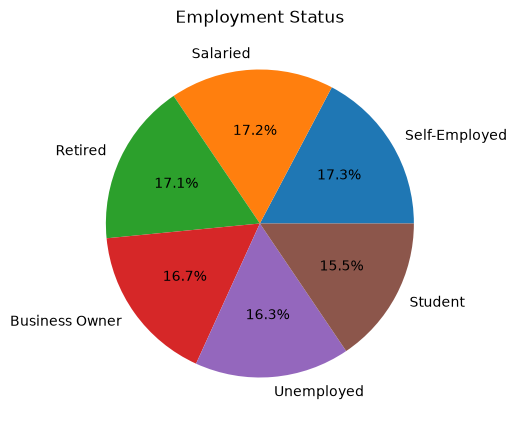

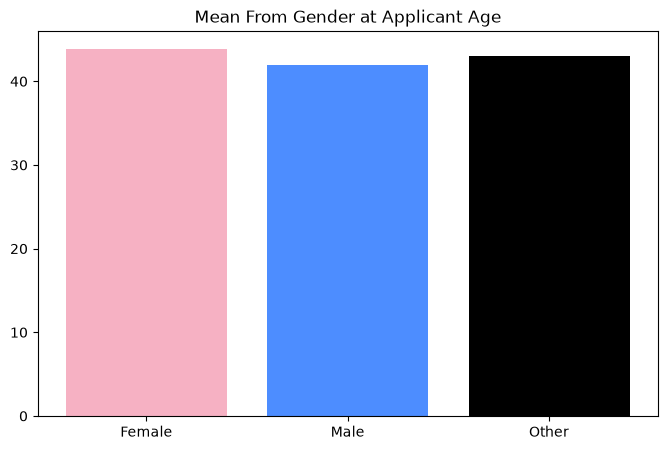

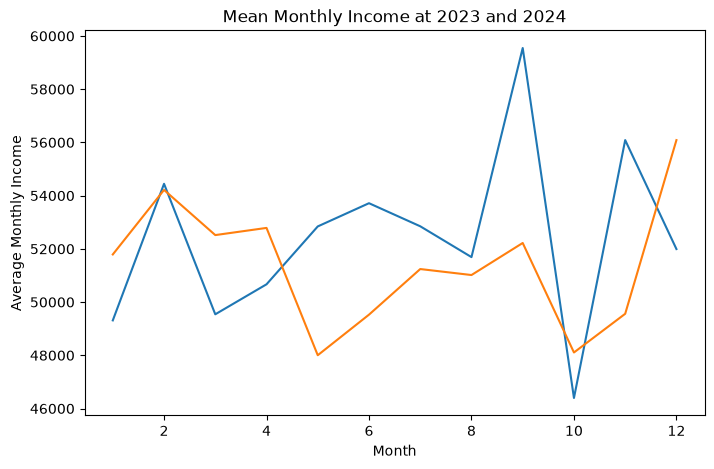

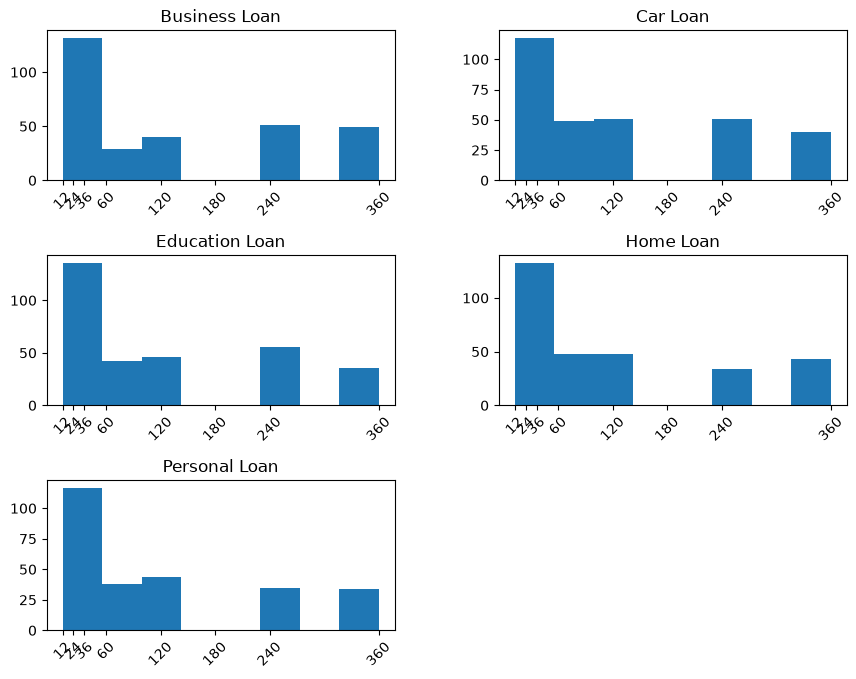

<Figure size 800x500 with 0 Axes>

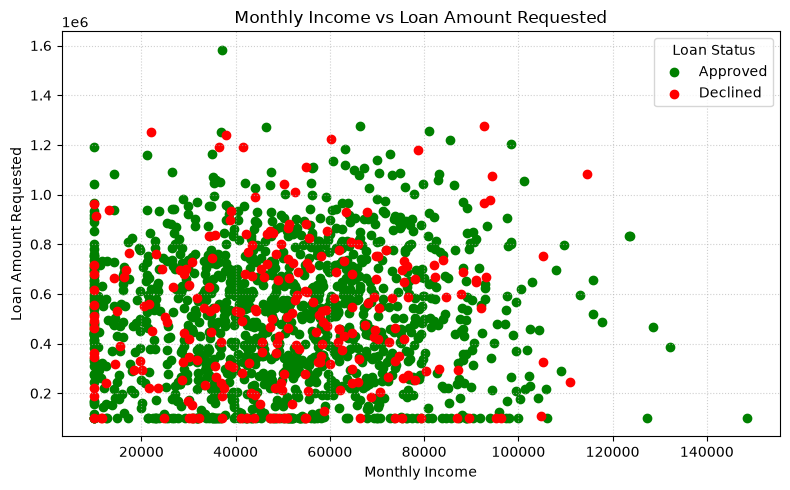

In [7]:
# Pie Charts Employment Status
df_employment_status = df['employment_status'].value_counts()
label_employment_status = ["Retired", "Unemployed","Salaried","Self-Employed","Student", "Business Owner"]
plt.figure(figsize=(8, 5))
plt.pie(df_employment_status, labels=df_employment_status.index, autopct='%1.1f%%')
plt.title("Employment Status")
plt.show()

# Bar Charts Mean Gender Age
group_gender = df['applicant_age'].groupby(df['gender']).mean()
label_gender = ["Female", "Male", "Other"]
color_gender = ["#F6B1C3", "#4D8DFF", "black"]
plt.figure(figsize=(8, 5))
plt.bar(label_gender, group_gender, color = color_gender)
plt.title("Mean From Gender at Applicant Age")
plt.show()

# Line Graph Plot Monthly Income Year 2023 and 2024 
df['year'] = pd.to_datetime(df["application_date"], format="mixed")

df_2023 = df[df["year"].dt.year == 2023]
df_2024 = df[df["year"].dt.year == 2024]

period_2023 = df_2023.groupby(df_2023["year"].dt.month)['monthly_income'].mean()
period_2024 = df_2024.groupby(df_2024["year"].dt.month)['monthly_income'].mean()

plt.figure(figsize=(8, 5))
plt.plot(period_2023.index, period_2023.values)
plt.plot(period_2024.index, period_2024.values)
plt.title("Mean Monthly Income at 2023 and 2024")
plt.ylabel("Average Monthly Income")
plt.xlabel("Month")
plt.show()

#Histogram Loan Tenore Month
nilai_unik = [12, 24, 36, 60, 120, 180, 240, 360]
df.hist(column='loan_tenure_months', by="loan_type", figsize=(10,8), bins=8, xrot=45)
for ax in plt.gcf().axes:
    ax.set_xticks(nilai_unik)
plt.figure(figsize=(8, 5))
plt.tight_layout()
plt.show()

#Scatter Plot Monthly Income vs Loan Amount Requested
approve = df[df["loan_status"] == "Approved"]
decline = df[df["loan_status"] == "Declined"]
plt.figure(figsize=(8, 5))

plt.scatter(approve["monthly_income"], approve["loan_amount_requested"], color = "green", label="Approved")
plt.scatter(decline["monthly_income"], decline["loan_amount_requested"], color = "red", label = "Declined")
plt.title("Monthly Income vs Loan Amount Requested")
plt.xlabel("Monthly Income")
plt.ylabel('Loan Amount Requested')
plt.legend(title='Loan Status')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



3. Correlation Analysis

                       interest_rate_offered  cibil_score
interest_rate_offered               1.000000     0.019351
cibil_score                         0.019351     1.000000


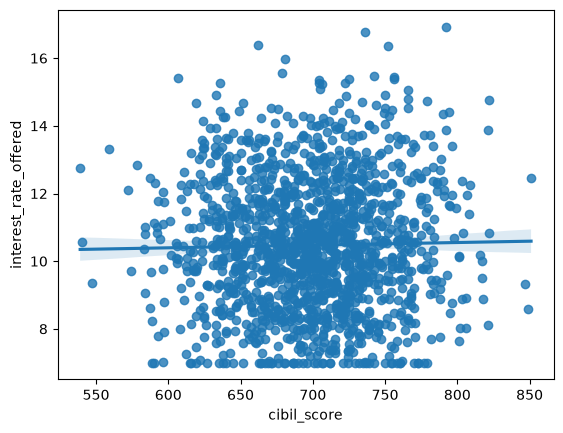

In [8]:
sns.regplot(x="cibil_score", y="interest_rate_offered", data=df)

status_kredit = df[['interest_rate_offered', 'cibil_score']].corr()

print(status_kredit)

JAWABAN NOMOR 3

Pada korelasi nomor 3 dapat dilihat bahwa antara interest rate offer dan cibil score tidak memiliki keterkaitan atau korelasi satu sama lainnya. Karena, secara teori risk based pricing nasabah dengan cibil skor tinggi harusnya mendapatkan interest rate offer yang rendah atau sebaliknya. Namun, pada dataset ini data tersebut tidak memiliki korelasi sama sekali dengan nilai yaitu 0.019.